Assignment II: Data Visualization

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [15]:
df = pd.read_csv("/content/train.csv")


1. Plot the distributions of all the numerical columns in the dataset using
histograms.


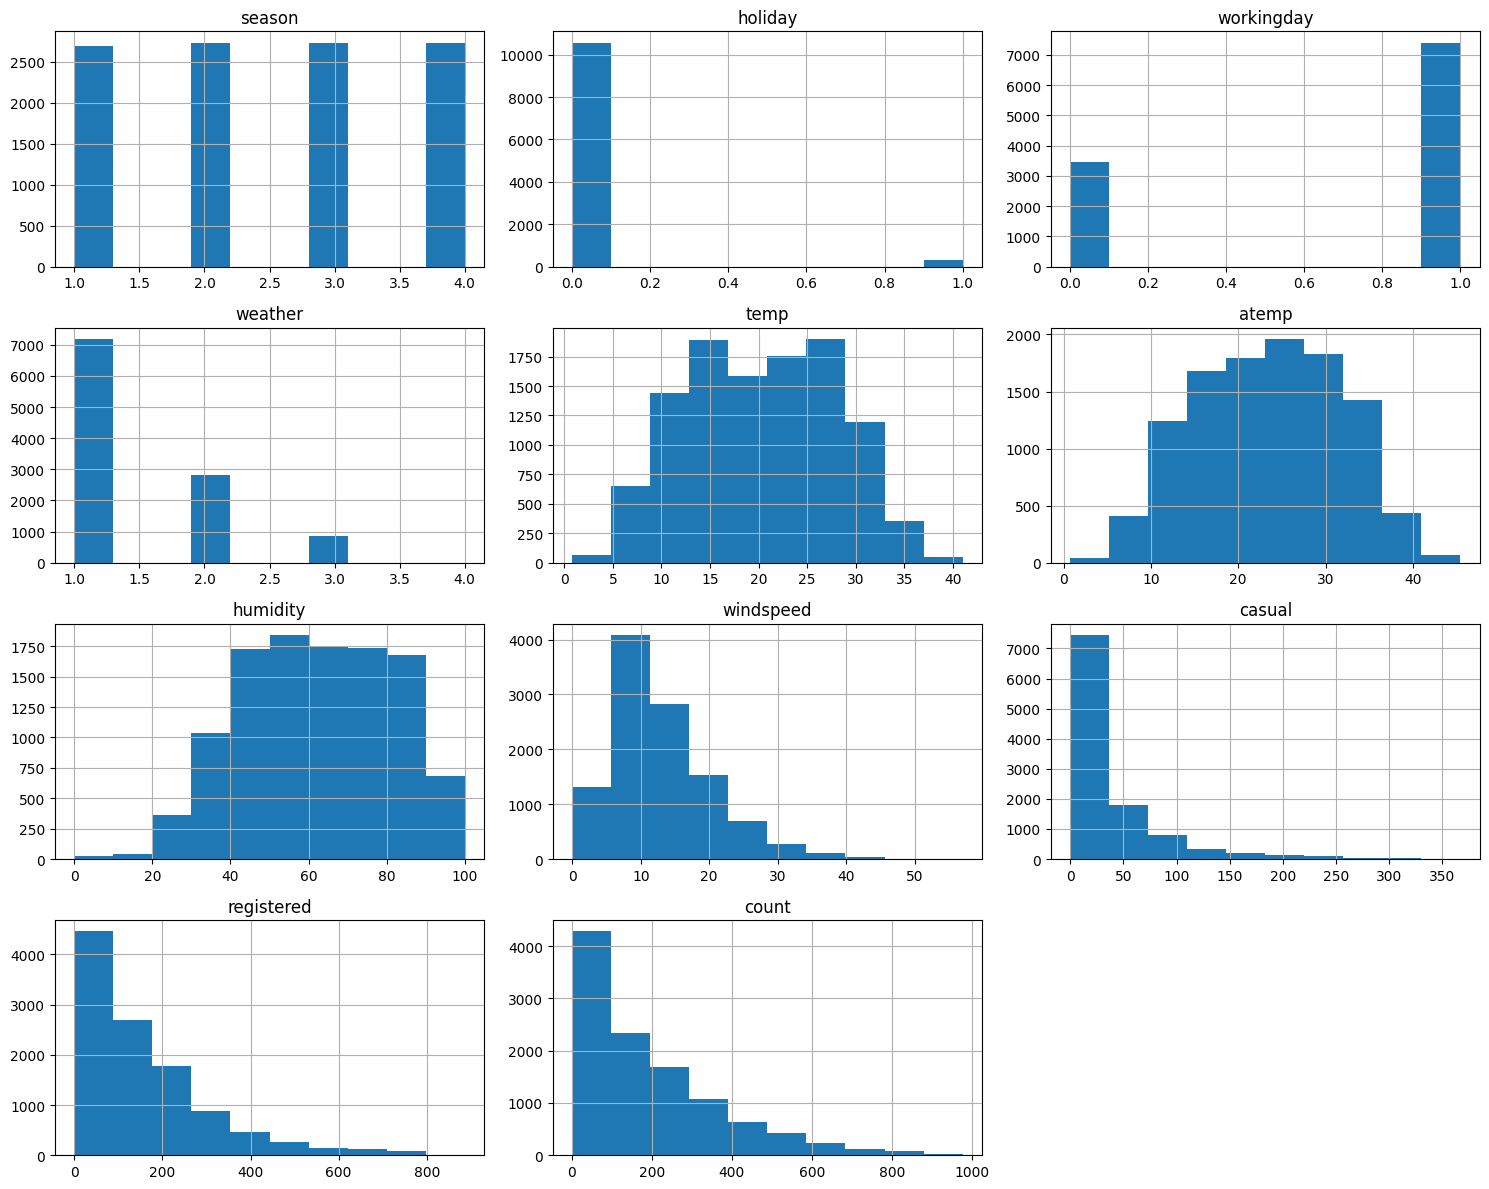

In [16]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()


2. Plot the distributions of all the numerical columns in the dataset using box
plots.

<Figure size 1500x1000 with 0 Axes>

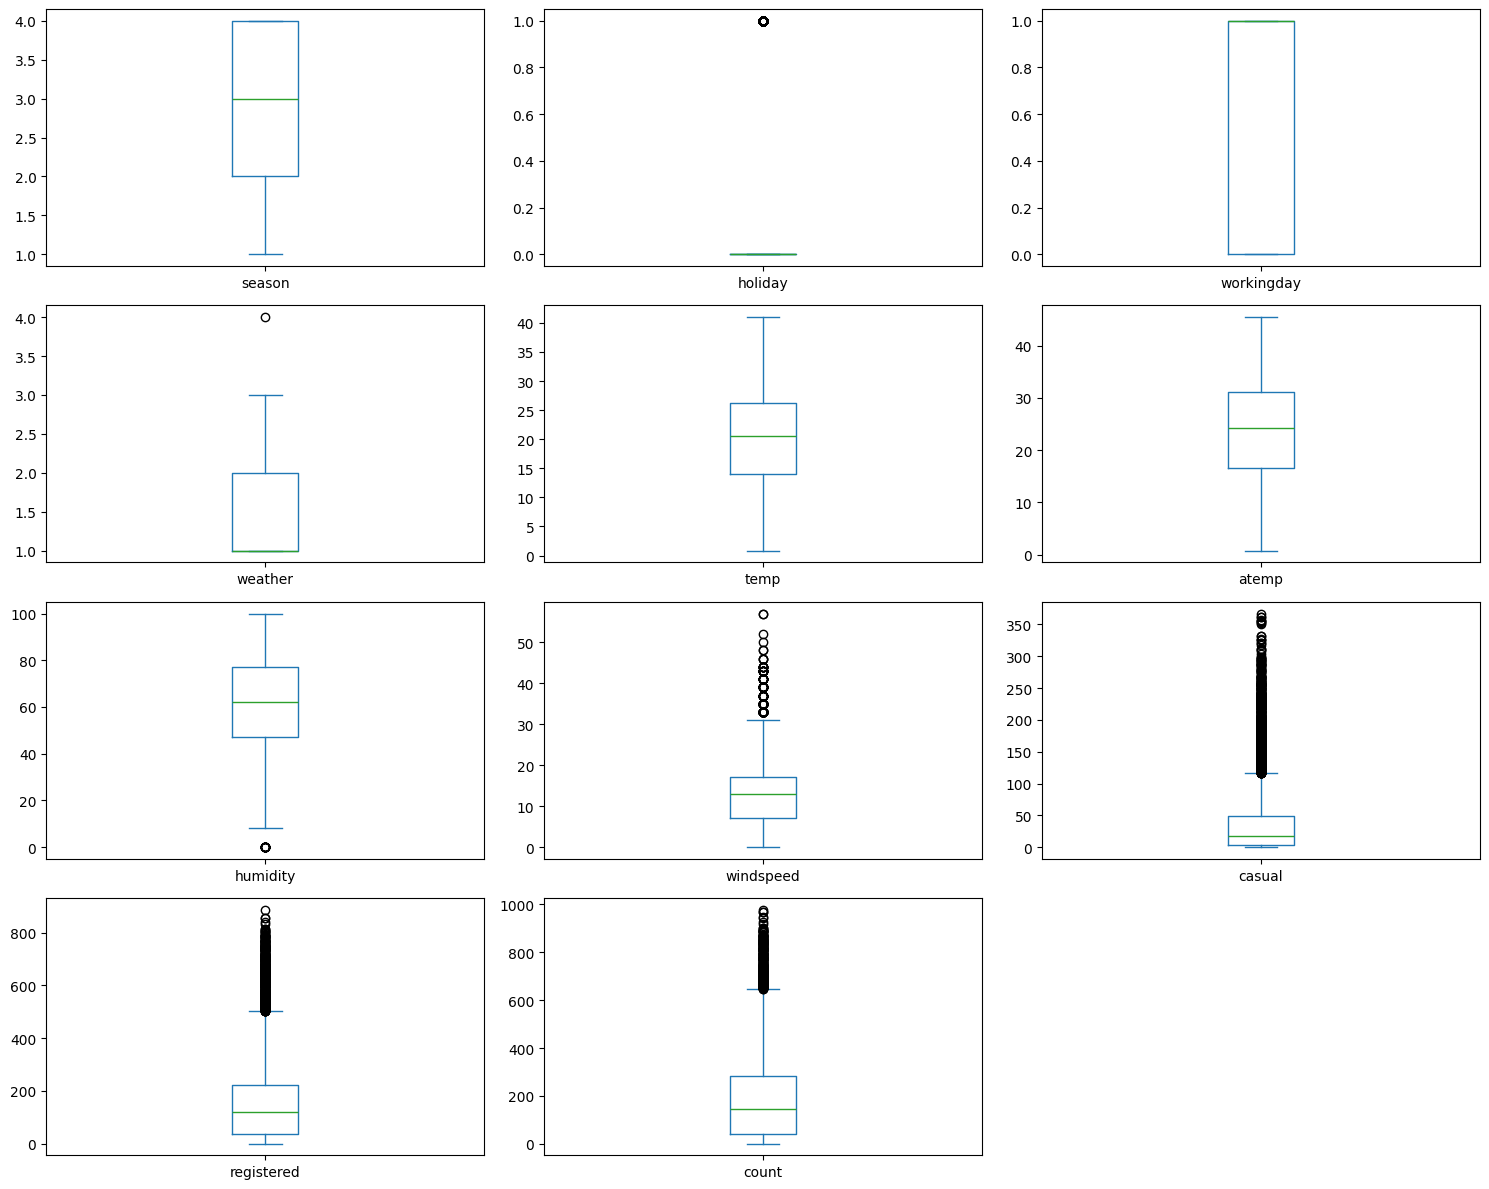

In [17]:
plt.figure(figsize=(15,10))
df[num_cols].plot(kind='box', subplots=True, layout=(len(num_cols)//3+1,3), figsize=(15,12), sharex=False)
plt.tight_layout()
plt.show()


3. Plot the the mean of the hourly total rentals count for working and non
working days.

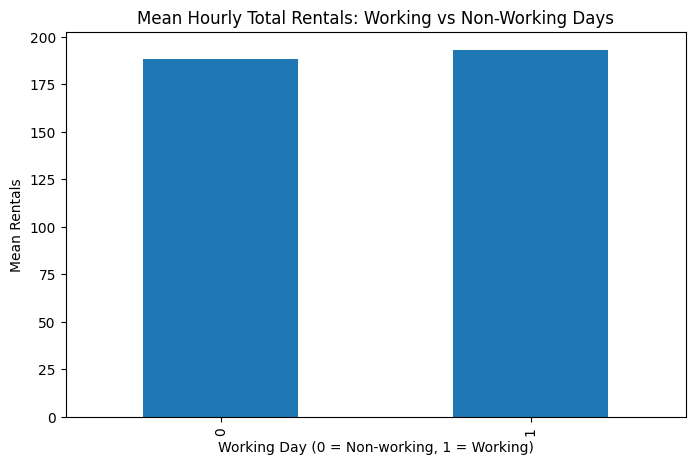

In [28]:
plt.figure(figsize=(8,5))
df.groupby('workingday')['count'].mean().plot(kind='bar')

plt.title("Mean Hourly Total Rentals: Working vs Non-Working Days")
plt.xlabel("Working Day (0 = Non-working, 1 = Working)")
plt.ylabel("Mean Rentals")
plt.show()

4. Plot the the mean of the hourly total rentals count for the different months for
both years combined.

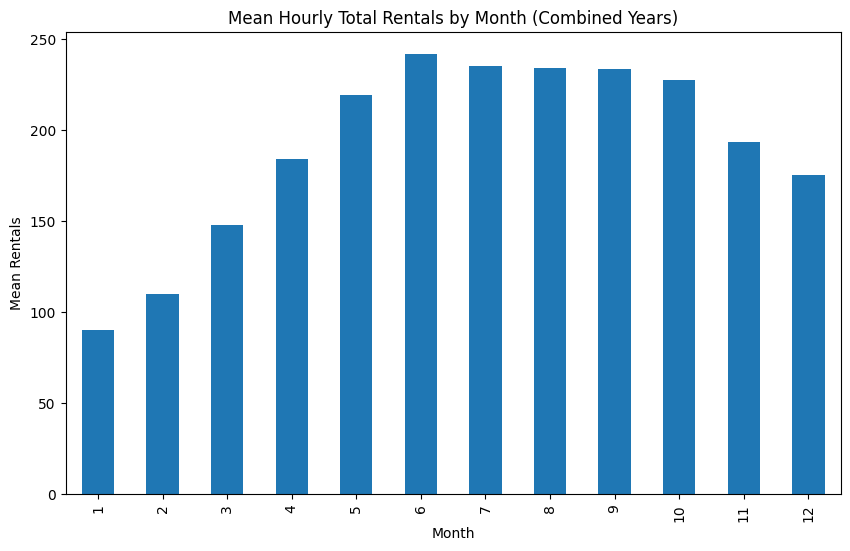

In [31]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
df['month'] = df['datetime'].dt.month

plt.figure(figsize=(10,6))
df.groupby('month')['count'].mean().plot(kind='bar')
plt.title("Mean Hourly Total Rentals by Month (Combined Years)")
plt.xlabel("Month")
plt.ylabel("Mean Rentals")
plt.show()

5. Plot the the mean of the hourly total rentals count for the different months for
both years separately in a multi-panel figure

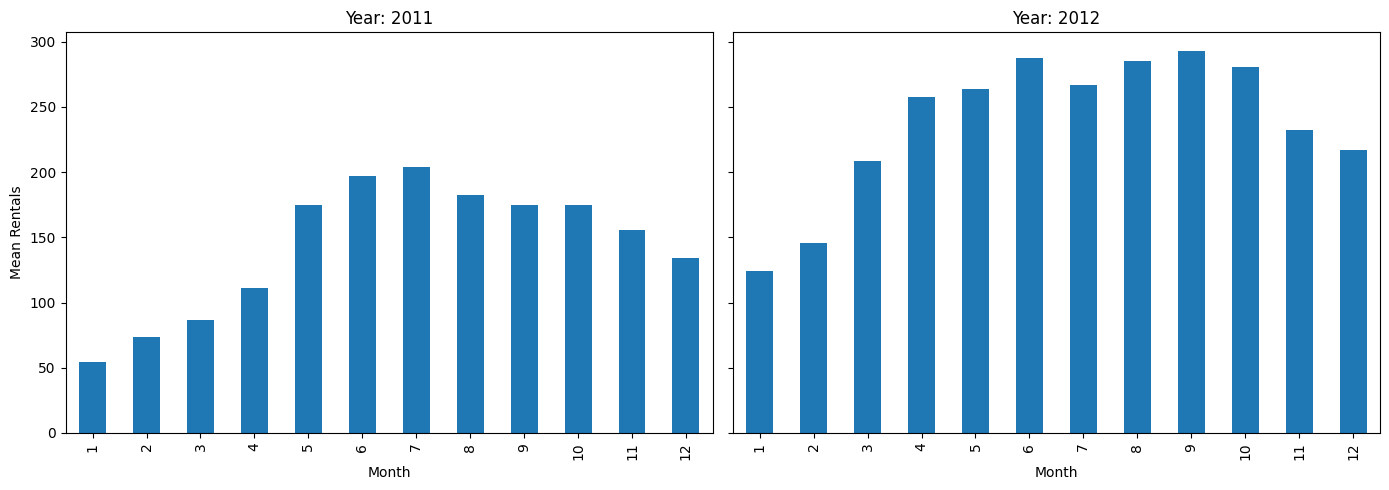

In [33]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

years = sorted(df['year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(14,5), sharey=True)

for i, y in enumerate(years):
    ax = axes[i]
    df[df['year'] == y].groupby('month')['count'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f"Year: {y}")
    ax.set_xlabel("Month")

axes[0].set_ylabel("Mean Rentals")
plt.tight_layout()
plt.show()

6. Plot the the mean and the 95% confidence interval of the hourly total rentals
count for the four different weather categories. What can you observe ?

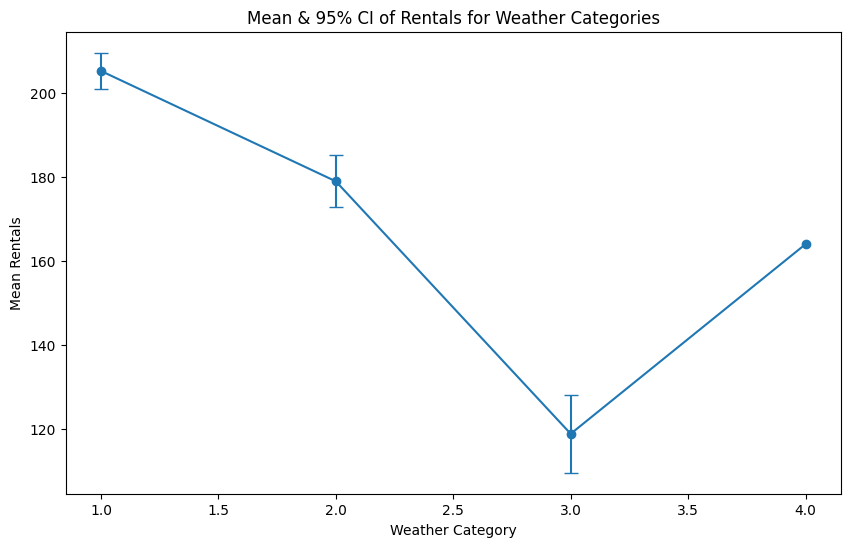

In [35]:
weather_stats = df.groupby('weather')['count'].agg(['mean','count','std'])
weather_stats['ci95'] = 1.96 * (weather_stats['std'] / np.sqrt(weather_stats['count']))

plt.figure(figsize=(10,6))
plt.errorbar(weather_stats.index, weather_stats['mean'],
             yerr=weather_stats['ci95'], fmt='o-', capsize=5)

plt.title("Mean & 95% CI of Rentals for Weather Categories")
plt.xlabel("Weather Category")
plt.ylabel("Mean Rentals")
plt.show()

7. Plot the the mean of the hourly total rentals count versus the hour of the day.
Which hours of the day have the highest rentals count ?

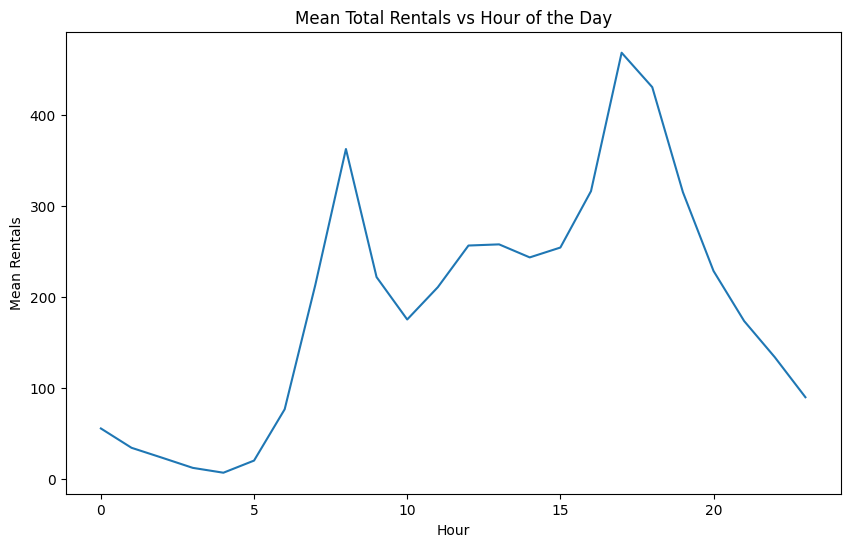

In [37]:
df['hour'] = df['datetime'].dt.hour

plt.figure(figsize=(10,6))
df.groupby('hour')['count'].mean().plot()

plt.title("Mean Total Rentals vs Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Mean Rentals")
plt.show()

8. Repeat the plot in 7 for different days of the week. What patterns can you
observe ?

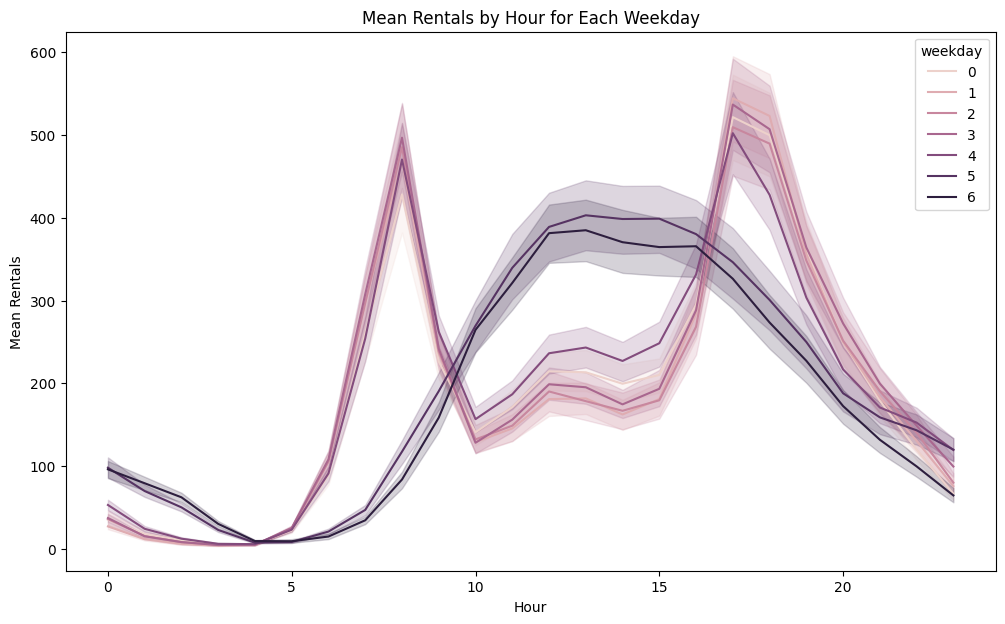

In [39]:
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek

plt.figure(figsize=(12,7))
sns.lineplot(x="hour", y="count", hue="weekday", data=df)

plt.title("Mean Rentals by Hour for Each Weekday")
plt.xlabel("Hour")
plt.ylabel("Mean Rentals")
plt.show()

9. Repeat the plot in 8 for the four seasons using a multi-panel figure. What
patterns can you observe ?

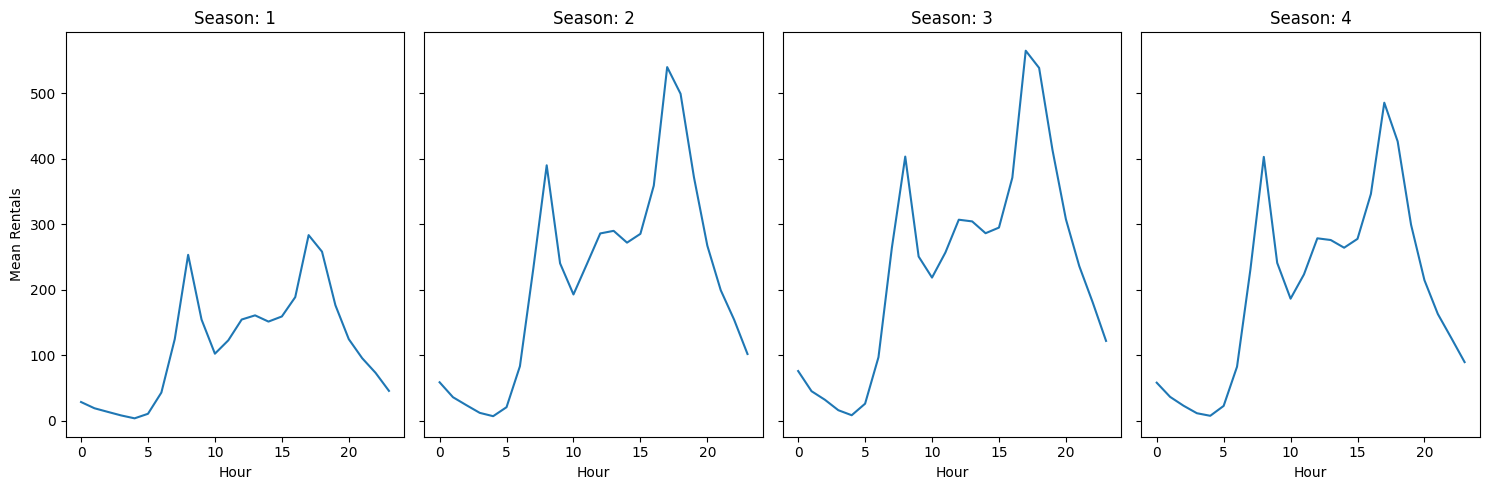

In [41]:
df['hour'] = df['datetime'].dt.hour
seasons = sorted(df['season'].unique())

fig, axes = plt.subplots(1, len(seasons), figsize=(15,5), sharey=True)

for i, s in enumerate(seasons):
    ax = axes[i]
    df[df['season']==s].groupby('hour')['count'].mean().plot(ax=ax)
    ax.set_title(f"Season: {s}")
    ax.set_xlabel("Hour")

axes[0].set_ylabel("Mean Rentals")
plt.tight_layout()
plt.show()

10. Plot the the mean  and the 95% confidence interval of the hourly total rentals
count versus the period of the day column, which you created in the first part
of the assignment. Which period of the day has the highest rentals count ?
Does this peak period differ for working and non-working days ?

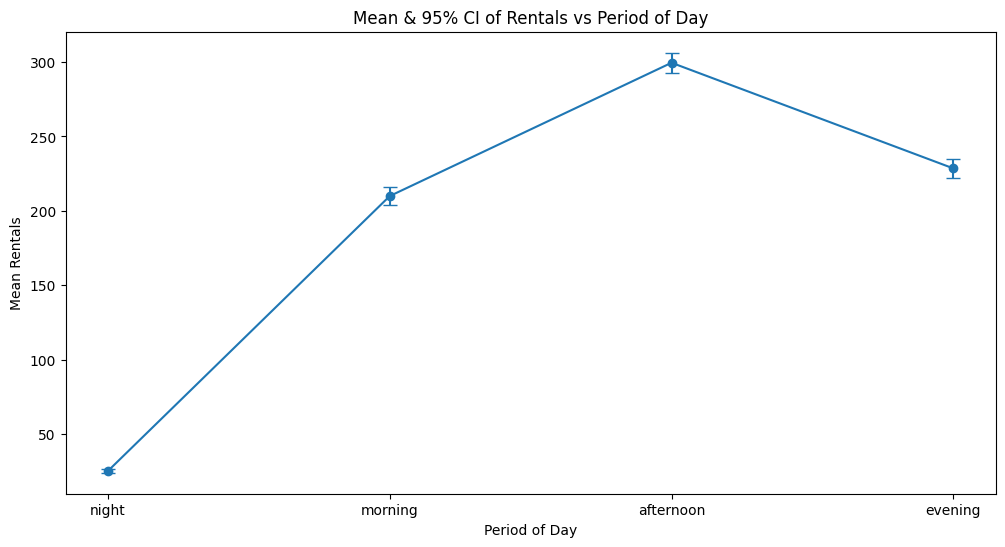

In [46]:
df['hour'] = df['datetime'].dt.hour
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
df['period_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False, ordered=False)

pod_stats = df.groupby('period_of_day', observed=False)['count'].agg(['mean','count','std'])
pod_stats['ci95'] = 1.96 * (pod_stats['std'] / np.sqrt(pod_stats['count']))

plt.figure(figsize=(12,6))
plt.errorbar(pod_stats.index, pod_stats['mean'],
             yerr=pod_stats['ci95'], fmt='o-', capsize=5)

plt.title("Mean & 95% CI of Rentals vs Period of Day")
plt.xlabel("Period of Day")
plt.ylabel("Mean Rentals")
plt.show()

11.  Plot a heatmap for the correlation matrix of the dataset numerical variables.
What observations can you make ?

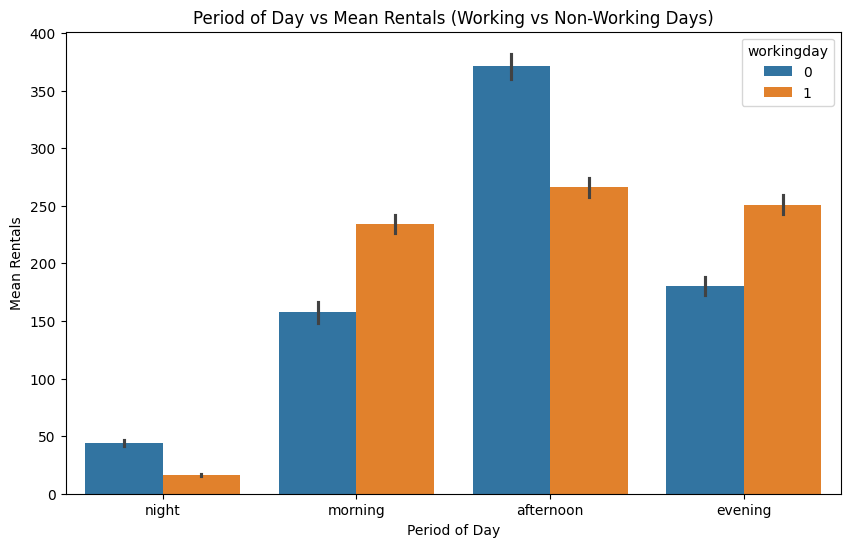

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="period_of_day", y="count", hue="workingday")

plt.title("Period of Day vs Mean Rentals (Working vs Non-Working Days)")
plt.xlabel("Period of Day")
plt.ylabel("Mean Rentals")
plt.show()